In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [2]:
Path("figures").mkdir(exist_ok=True)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

tips["tip_percentage"] = 100 * tips["tip"] / tips["total_bill"]

In [3]:
tips

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


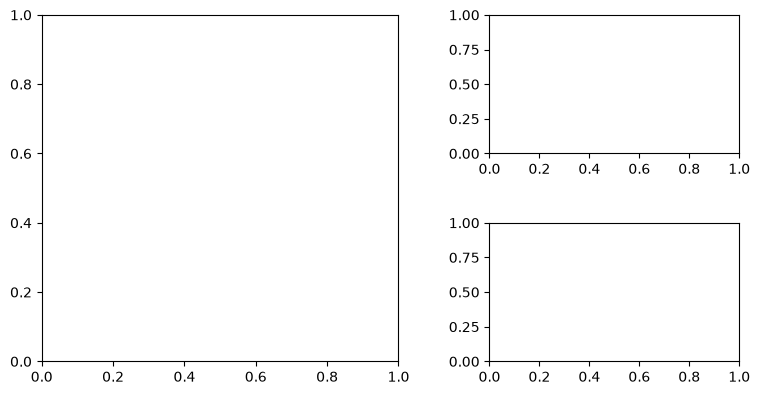

In [4]:
fig, axes = plt.subplot_mosaic(
    """
    AB
    AC
    """,
    figsize=(9, 4.5),
    sharex=False,
    sharey=False,
    gridspec_kw={
        "hspace": 0.5,
        "wspace": 0.3,
        "height_ratios": [1, 1],
        "width_ratios": [1, 0.7],
    },
)

In [5]:
slope, intercept = np.polyfit(tips["total_bill"], tips["tip"], 1)

x = np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 100)
y = slope * x + intercept

axes["A"].scatter(
    tips["total_bill"],
    tips["tip"],
    label="Observations",
    alpha=0.7,
)

axes["A"].plot(
    x,
    y,
    color="black",
    linewidth=2,
    label=rf"Linear fit: $y = {slope:.3f}x + {intercept:.3f}$",
)

axes["A"].legend(frameon=False)
axes["A"].set_xlabel("Total bill ($)")
axes["A"].set_ylabel("Tip ($)")

Text(4.444444444444452, 0.5, 'Tip ($)')

In [6]:
plt.show()